# Unified Comparison: ARIMA vs LSTM vs LSTM-SGARCH

This notebook compares three models on the same **daily log-return target**:

```text
r_t = log(P_t / P_{t-1})
```

Models:
- ARIMA (configuration from the daily-return ARIMA benchmark notebook),
- LSTM (best run outputs),
- LSTM-SGARCH (best run outputs).

It generates one large comparison chart with rolling metric windows and an overall metrics table.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

TIMESTAMP_COL = 'timestamp_utc'
TARGET_COL = 'target_next_daily_log_return'

RAW_5MIN_PATH = Path('data/BTC/BTC_USD_coinbase_spot_5min.csv')
ARIMA_NOTEBOOK_PATH = Path('ARIMA_volatility.ipynb')
ARIMA_META_PATH = Path('artifacts/arima_daily_return/arima_model_metadata.json')

LSTM_META_PATH = Path('artifacts/lstm_walk_forward/grid_search/best_model_metadata.json')
LSTM_PRED_PATH = Path('artifacts/lstm_walk_forward/final_evaluation/test_predictions.csv')

HYBRID_META_PATH = Path('artifacts/lstm_sgarch_walk_forward/grid_search/best_model_metadata.json')
HYBRID_PRED_PATH = Path('artifacts/lstm_sgarch_walk_forward/final_evaluation/test_predictions.csv')

OUT_DIR = Path('artifacts/model_comparison_daily')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_WINDOW_DAYS = 30
ROLLING_WINDOWS = [5, 7, 10]
EPS = 1e-12

for p in [RAW_5MIN_PATH, ARIMA_NOTEBOOK_PATH, LSTM_META_PATH, LSTM_PRED_PATH, HYBRID_META_PATH, HYBRID_PRED_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file: {p}')


In [2]:
def extract_arima_config_from_notebook(notebook_path: Path, metadata_path: Path = ARIMA_META_PATH) -> dict:
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        order = metadata['selected_order']
        return {
            'p': int(order['p']),
            'd': int(order['d']),
            'q': int(order['q']),
            'trend': str(metadata['trend']),
            'source': str(metadata_path),
        }

    nb = json.loads(notebook_path.read_text(encoding='utf-8'))
    pattern = re.compile(r'Selected ARIMA\((\d+),\s*(\d+),\s*(\d+)\), trend=([A-Za-z0-9_+-]+)')

    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for output in cell.get('outputs', []):
            text_parts = []
            if isinstance(output.get('text'), list):
                text_parts.extend(output['text'])
            elif isinstance(output.get('text'), str):
                text_parts.append(output['text'])

            data = output.get('data', {}) if isinstance(output, dict) else {}
            if isinstance(data, dict):
                txt = data.get('text/plain')
                if isinstance(txt, list):
                    text_parts.extend(txt)
                elif isinstance(txt, str):
                    text_parts.append(txt)

            blob = '\n'.join(text_parts)
            m = pattern.search(blob)
            if m:
                return {
                    'p': int(m.group(1)),
                    'd': int(m.group(2)),
                    'q': int(m.group(3)),
                    'trend': str(m.group(4)),
                    'source': str(notebook_path),
                }

    raise RuntimeError(
        'ARIMA configuration was not found. Run ARIMA_volatility.ipynb after the daily-return rewrite '
        'so it writes artifacts/arima_daily_return/arima_model_metadata.json.'
    )

def build_daily_target_frame(raw_5m_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(raw_5m_path)
    raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], utc=True)
    raw = raw.sort_values(TIMESTAMP_COL).reset_index(drop=True)

    raw['log_close_5m'] = np.log(raw['close'])
    raw['log_return_5m'] = raw['log_close_5m'].diff()

    daily = raw.set_index(TIMESTAMP_COL).resample('1D').agg(close=('close', 'last'))
    daily_intraday_vol = raw.set_index(TIMESTAMP_COL)['log_return_5m'].resample('1D').std().rename('daily_volatility')
    daily = daily.join(daily_intraday_vol)

    daily['daily_log_return'] = np.log(daily['close'] / daily['close'].shift(1))
    daily['volatility_7d'] = daily['daily_volatility'].rolling(7).mean()
    daily[TARGET_COL] = daily['daily_log_return'].shift(-1)

    return daily.reset_index()[[TIMESTAMP_COL, 'daily_log_return', 'daily_volatility', 'volatility_7d', TARGET_COL]].dropna().reset_index(drop=True)


def model_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    err = y_pred - y_true
    denom = np.abs(y_true) + np.abs(y_pred) + EPS

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(err) / (np.abs(y_true) + EPS)) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / denom) * 100.0)

    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    sse = float(np.sum(err ** 2))
    r2 = float(1.0 - sse / sst) if sst > EPS else float('nan')

    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > EPS and np.std(y_pred) > EPS) else float('nan')
    direction_acc = float(np.mean(np.sign(y_true) == np.sign(y_pred)))

    return {
        'rmse': rmse,
        'mae': mae,
        'mape_pct': mape,
        'smape_pct': smape,
        'r2': r2,
        'correlation': corr,
        'direction_accuracy': direction_acc,
    }


In [3]:
# Build target frame and load best-model prediction artifacts
df = build_daily_target_frame(RAW_5MIN_PATH)

with LSTM_META_PATH.open('r', encoding='utf-8') as f:
    lstm_meta = json.load(f)
with HYBRID_META_PATH.open('r', encoding='utf-8') as f:
    hybrid_meta = json.load(f)

lstm_df = pd.read_csv(LSTM_PRED_PATH)
lstm_df[TIMESTAMP_COL] = pd.to_datetime(lstm_df[TIMESTAMP_COL], utc=True)
lstm_df = lstm_df.rename(columns={'y_true': 'y_true_lstm', 'y_pred': 'lstm_pred'})

hybrid_df = pd.read_csv(HYBRID_PRED_PATH)
hybrid_df[TIMESTAMP_COL] = pd.to_datetime(hybrid_df[TIMESTAMP_COL], utc=True)
hybrid_df = hybrid_df.rename(columns={'y_true': 'y_true_hybrid', 'lstm_mean_pred': 'lstm_sgarch_pred'})

base = lstm_df[[TIMESTAMP_COL, 'fold_id', 'y_true_lstm', 'lstm_pred']].merge(
    hybrid_df[[TIMESTAMP_COL, 'y_true_hybrid', 'lstm_sgarch_pred', 'sgarch_vol_pred']],
    on=TIMESTAMP_COL,
    how='inner',
)

if base.empty:
    raise RuntimeError('No overlapping timestamps between LSTM and LSTM-SGARCH predictions')

if not np.allclose(base['y_true_lstm'].to_numpy(), base['y_true_hybrid'].to_numpy(), atol=1e-12):
    raise RuntimeError('Mismatch between LSTM and LSTM-SGARCH y_true values')

base = base.rename(columns={'y_true_lstm': 'y_true'}).drop(columns=['y_true_hybrid'])
base = base.sort_values([TIMESTAMP_COL, 'fold_id']).reset_index(drop=True)

print('LSTM best params:', lstm_meta['best_params'])
print('LSTM-SGARCH best params:', hybrid_meta['best_params'])
print('Aligned rows:', len(base))
base.head()


LSTM best params: {'seq_len': 10, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.0005, 'batch_size': 8}
LSTM-SGARCH best params: {'seq_len': 7, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
Aligned rows: 30


,timestamp_utc,fold_id,y_true,lstm_pred,lstm_sgarch_pred,sgarch_vol_pred
0,2026-03-13 00:00:00+00:00,0,0.004047,-0.000124,-0.007333,0.037996
1,2026-03-14 00:00:00+00:00,0,0.022186,-0.000151,-0.014069,0.036545
2,2026-03-15 00:00:00+00:00,0,0.027845,-0.000152,-0.050715,0.036021
3,2026-03-16 00:00:00+00:00,1,-0.012799,0.006143,0.018226,0.041022
4,2026-03-17 00:00:00+00:00,1,-0.037049,0.006143,0.007964,0.039967


In [4]:
# ARIMA from the daily-return benchmark notebook + walk-forward on the same fold timestamps
arima_cfg = extract_arima_config_from_notebook(ARIMA_NOTEBOOK_PATH, ARIMA_META_PATH)
print('ARIMA config from notebook:', arima_cfg)

target_by_ts = df.set_index(TIMESTAMP_COL)[TARGET_COL].astype(float)

arima_rows = []
for fold_id, fold_df in base.groupby('fold_id', sort=True):
    fold_df = fold_df.sort_values(TIMESTAMP_COL)
    eval_ts = fold_df[TIMESTAMP_COL].tolist()
    eval_start = eval_ts[0]
    train_end = eval_start
    train_start = train_end - pd.Timedelta(days=TRAIN_WINDOW_DAYS)

    train_series = target_by_ts[(target_by_ts.index >= train_start) & (target_by_ts.index < train_end)]
    if len(train_series) < 10:
        raise RuntimeError(f'Not enough ARIMA train observations for fold {fold_id}: {len(train_series)}')

    state = ARIMA(
        train_series.to_numpy(dtype=float),
        order=(arima_cfg['p'], arima_cfg['d'], arima_cfg['q']),
        trend=arima_cfg['trend'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

    for ts in eval_ts:
        pred = float(state.forecast(steps=1)[0])
        actual = float(target_by_ts.loc[ts])
        arima_rows.append({TIMESTAMP_COL: ts, 'fold_id': int(fold_id), 'arima_pred': pred, 'y_true_arima': actual})
        state = state.append([actual], refit=False)

arima_df = pd.DataFrame(arima_rows).sort_values([TIMESTAMP_COL, 'fold_id']).reset_index(drop=True)

comp = base.merge(arima_df[[TIMESTAMP_COL, 'fold_id', 'arima_pred', 'y_true_arima']], on=[TIMESTAMP_COL, 'fold_id'], how='inner')
if comp.empty:
    raise RuntimeError('No overlap after merging ARIMA predictions')

if not np.allclose(comp['y_true'].to_numpy(), comp['y_true_arima'].to_numpy(), atol=1e-12):
    raise RuntimeError('ARIMA y_true mismatch on aligned rows')

comp = comp.drop(columns=['y_true_arima']).sort_values([TIMESTAMP_COL, 'fold_id']).reset_index(drop=True)

with (OUT_DIR / 'arima_model_from_notebook.json').open('w', encoding='utf-8') as f:
    json.dump(arima_cfg, f, indent=2)

comp.head()


ARIMA config from notebook: {'p': 2, 'd': 0, 'q': 1, 'trend': 'c', 'source': 'ARIMA_volatility.ipynb'}


/mnt/c/Users/suchy/Studia/Masters/RR/LSTM_SGARCH_rr/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/Users/suchy/Studia/Masters/RR/LSTM_SGARCH_rr/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/Users/suchy/Studia/Masters/RR/LSTM_SGARCH_rr/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/Users/suchy/Studia/Masters/RR/LSTM_SGARCH_rr/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Che

,timestamp_utc,fold_id,y_true,lstm_pred,lstm_sgarch_pred,sgarch_vol_pred,arima_pred
0,2026-03-13 00:00:00+00:00,0,0.004047,-0.000124,-0.007333,0.037996,-0.008953
1,2026-03-14 00:00:00+00:00,0,0.022186,-0.000151,-0.014069,0.036545,-0.008385
2,2026-03-15 00:00:00+00:00,0,0.027845,-0.000152,-0.050715,0.036021,-0.012152
3,2026-03-16 00:00:00+00:00,1,-0.012799,0.006143,0.018226,0.041022,-0.005276
4,2026-03-17 00:00:00+00:00,1,-0.037049,0.006143,0.007964,0.039967,-0.001010


In [5]:
# Metrics: overall and rolling windows
models = {
    'ARIMA': comp['arima_pred'].to_numpy(dtype=float),
    'LSTM': comp['lstm_pred'].to_numpy(dtype=float),
    'LSTM-SGARCH': comp['lstm_sgarch_pred'].to_numpy(dtype=float),
}
y_true = comp['y_true'].to_numpy(dtype=float)

overall_rows = []
for name, pred in models.items():
    overall_rows.append({'model': name, **model_metrics(y_true, pred)})

overall_df = pd.DataFrame(overall_rows).sort_values('rmse').reset_index(drop=True)

rolling_rows = []
for w in ROLLING_WINDOWS:
    for i in range(w - 1, len(comp)):
        ys = y_true[i - w + 1:i + 1]
        ts = comp.loc[i, TIMESTAMP_COL]
        for name, pred in models.items():
            ps = pred[i - w + 1:i + 1]
            m = model_metrics(ys, ps)
            rolling_rows.append({
                TIMESTAMP_COL: ts,
                'window': int(w),
                'model': name,
                'rmse': m['rmse'],
                'mae': m['mae'],
                'direction_accuracy': m['direction_accuracy'],
            })

rolling_df = pd.DataFrame(rolling_rows)

comp.to_csv(OUT_DIR / 'test_predictions_aligned.csv', index=False)
overall_df.to_csv(OUT_DIR / 'overall_metrics.csv', index=False)
rolling_df.to_csv(OUT_DIR / 'rolling_window_metrics.csv', index=False)

print('Saved:')
print(' -', OUT_DIR / 'test_predictions_aligned.csv')
print(' -', OUT_DIR / 'overall_metrics.csv')
print(' -', OUT_DIR / 'rolling_window_metrics.csv')
overall_df


Saved:
 - artifacts/model_comparison_daily/test_predictions_aligned.csv
 - artifacts/model_comparison_daily/overall_metrics.csv
 - artifacts/model_comparison_daily/rolling_window_metrics.csv


,model,rmse,mae,mape_pct,smape_pct,r2,correlation,direction_accuracy
0,LSTM,0.021907,0.017668,110.517102,174.315084,-0.048923,0.030969,0.566667
1,ARIMA,0.026249,0.020850,211.574776,155.595917,-0.505945,-0.129642,0.433333
2,LSTM-SGARCH,0.070476,0.052921,1055.138915,158.656258,-9.855776,0.101866,0.466667


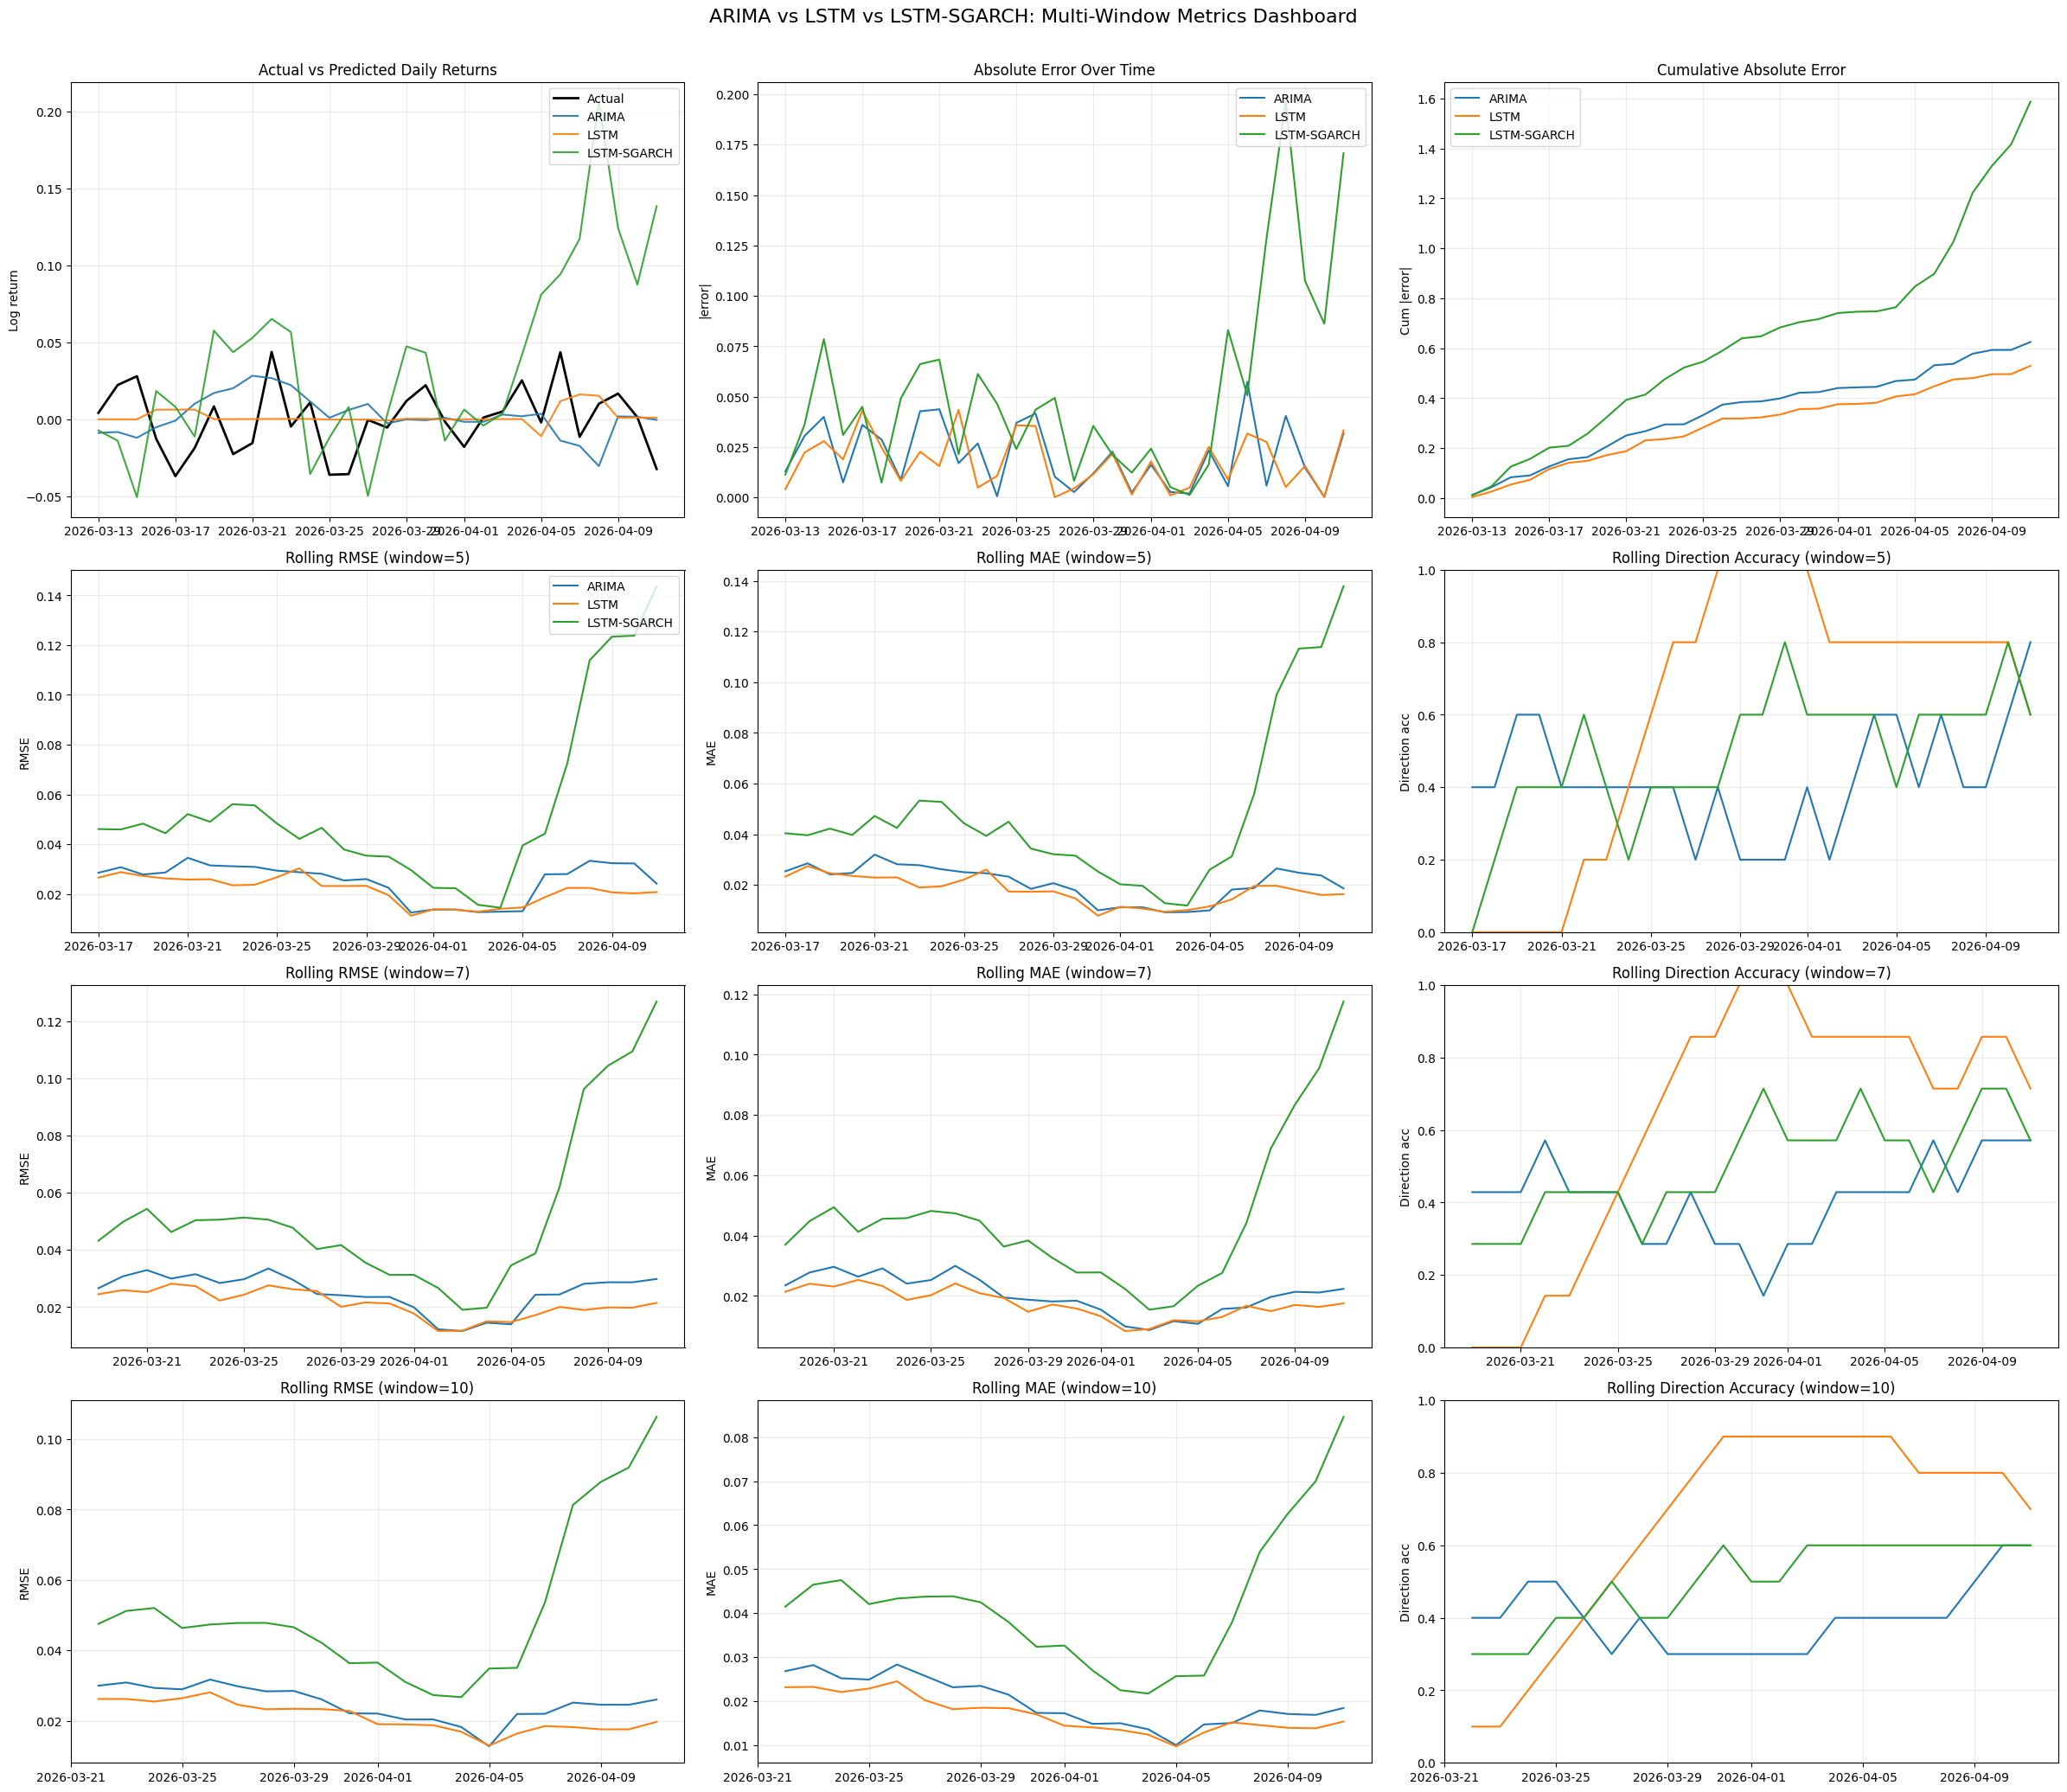

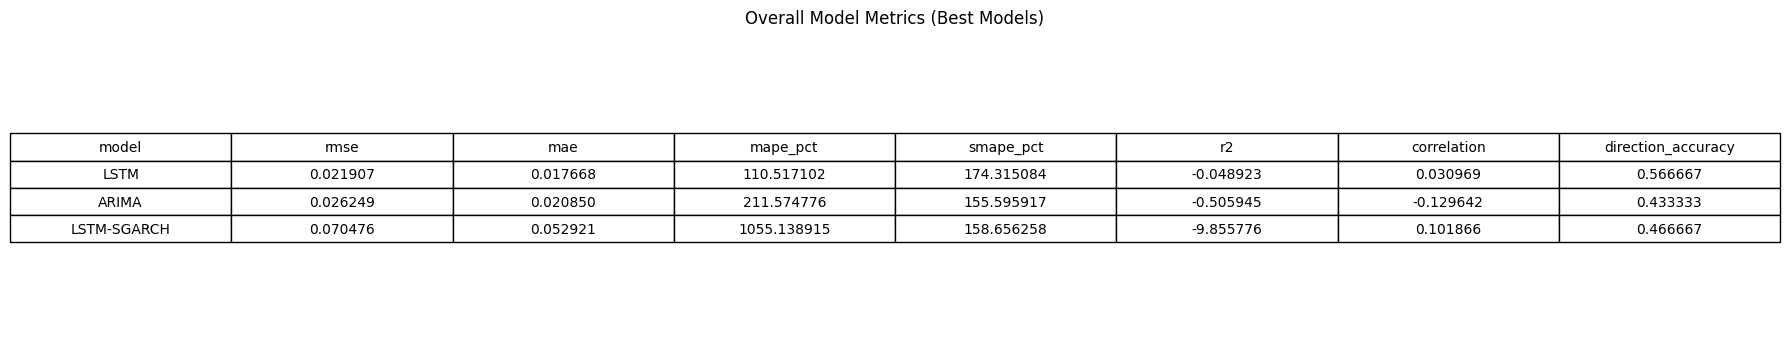

Saved plots:
 - artifacts/model_comparison_daily/comparison_big_chart_windows.png
 - artifacts/model_comparison_daily/comparison_overall_metrics_table.png


In [6]:
# One big chart with windows (rolling metrics + overall table)
plot_df = comp.copy().sort_values(TIMESTAMP_COL)
plot_df[TIMESTAMP_COL] = pd.to_datetime(plot_df[TIMESTAMP_COL], utc=True)

fig = plt.figure(figsize=(24, 26))
gs = fig.add_gridspec(5, 3, height_ratios=[1.2, 1.0, 1.0, 1.0, 1.15])

ax_pred = fig.add_subplot(gs[0, 0])
ax_abs = fig.add_subplot(gs[0, 1])
ax_cum = fig.add_subplot(gs[0, 2])

ax_pred.plot(plot_df[TIMESTAMP_COL], plot_df['y_true'], label='Actual', color='black', linewidth=2.0)
ax_pred.plot(plot_df[TIMESTAMP_COL], plot_df['arima_pred'], label='ARIMA', alpha=0.9)
ax_pred.plot(plot_df[TIMESTAMP_COL], plot_df['lstm_pred'], label='LSTM', alpha=0.9)
ax_pred.plot(plot_df[TIMESTAMP_COL], plot_df['lstm_sgarch_pred'], label='LSTM-SGARCH', alpha=0.9)
ax_pred.set_title('Actual vs Predicted Daily Returns')
ax_pred.set_ylabel('Log return')
ax_pred.grid(alpha=0.25)
ax_pred.legend(loc='upper right')

for col, name in [('arima_pred', 'ARIMA'), ('lstm_pred', 'LSTM'), ('lstm_sgarch_pred', 'LSTM-SGARCH')]:
    ax_abs.plot(plot_df[TIMESTAMP_COL], np.abs(plot_df[col] - plot_df['y_true']), label=name)
ax_abs.set_title('Absolute Error Over Time')
ax_abs.set_ylabel('|error|')
ax_abs.grid(alpha=0.25)
ax_abs.legend(loc='upper right')

for col, name in [('arima_pred', 'ARIMA'), ('lstm_pred', 'LSTM'), ('lstm_sgarch_pred', 'LSTM-SGARCH')]:
    ax_cum.plot(plot_df[TIMESTAMP_COL], np.cumsum(np.abs(plot_df[col] - plot_df['y_true'])), label=name)
ax_cum.set_title('Cumulative Absolute Error')
ax_cum.set_ylabel('Cum |error|')
ax_cum.grid(alpha=0.25)
ax_cum.legend(loc='upper left')

for r, w in enumerate(ROLLING_WINDOWS, start=1):
    ax_rmse = fig.add_subplot(gs[r, 0])
    ax_mae = fig.add_subplot(gs[r, 1])
    ax_dir = fig.add_subplot(gs[r, 2])

    rw = rolling_df[rolling_df['window'] == w].copy()
    rw[TIMESTAMP_COL] = pd.to_datetime(rw[TIMESTAMP_COL], utc=True)

    for name in ['ARIMA', 'LSTM', 'LSTM-SGARCH']:
        part = rw[rw['model'] == name].sort_values(TIMESTAMP_COL)
        ax_rmse.plot(part[TIMESTAMP_COL], part['rmse'], label=name)
        ax_mae.plot(part[TIMESTAMP_COL], part['mae'], label=name)
        ax_dir.plot(part[TIMESTAMP_COL], part['direction_accuracy'], label=name)

    ax_rmse.set_title(f'Rolling RMSE (window={w})')
    ax_mae.set_title(f'Rolling MAE (window={w})')
    ax_dir.set_title(f'Rolling Direction Accuracy (window={w})')

    ax_rmse.grid(alpha=0.25)
    ax_mae.grid(alpha=0.25)
    ax_dir.grid(alpha=0.25)

    ax_rmse.set_ylabel('RMSE')
    ax_mae.set_ylabel('MAE')
    ax_dir.set_ylabel('Direction acc')
    ax_dir.set_ylim(0.0, 1.0)

    if r == 1:
        ax_rmse.legend(loc='upper right')

# Overall metrics table on separate figure for readability
fig2, ax_tbl = plt.subplots(figsize=(18, 3.6))
ax_tbl.axis('off')
cols = ['model', 'rmse', 'mae', 'mape_pct', 'smape_pct', 'r2', 'correlation', 'direction_accuracy']
tbl_data = overall_df[cols].copy()
for c in cols[1:]:
    tbl_data[c] = tbl_data[c].map(lambda x: f'{x:.6f}')

table = ax_tbl.table(
    cellText=tbl_data.values,
    colLabels=tbl_data.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax_tbl.set_title('Overall Model Metrics (Best Models)', pad=10)

fig.suptitle('ARIMA vs LSTM vs LSTM-SGARCH: Multi-Window Metrics Dashboard', fontsize=16, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig2.tight_layout()

fig.savefig(OUT_DIR / 'comparison_big_chart_windows.png', dpi=180, bbox_inches='tight')
fig2.savefig(OUT_DIR / 'comparison_overall_metrics_table.png', dpi=180, bbox_inches='tight')

plt.show()

print('Saved plots:')
print(' -', OUT_DIR / 'comparison_big_chart_windows.png')
print(' -', OUT_DIR / 'comparison_overall_metrics_table.png')
